# Model Calibration

**Author:** Bilal Saleh Husain

---

This notebook demonstrates calibrating structural model parameters to a default probability curve. The pipeline is as follows:

$$
\text{Model params } \theta \;\xrightarrow{\text{Fokker-Planck}}\; p(v, T) \;\xrightarrow{\int_0^K}\; P(\text{default by } T)
$$

We validate on the Merton model. For models without closed-form solutions, the PINN-solved density replaces the analytical formula.

**Sections**:
1. Mathematical framework
2. Forward problem: parameters → default probabilities
3. Inverse problem: default probabilities → recovered parameters

## Setup and Imports

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm

sys.path.insert(0, str(Path.cwd().parent / 'src'))

from pinn_sgm.calibration import Calibrator
from pinn_sgm.visualizations import setup_publication_style

setup_publication_style()
%config InlineBackend.figure_format = 'retina'

In [2]:
np.random.seed(42)

## Part 1: Mathematical Framework

In the Merton model, the firm's asset value $V_t$ follows geometric Brownian motion:
$$
dV_t = r\, V_t\, dt + \sigma\, V_t\, dW_t
$$

The firm defaults when $V_T < K$. The **default probability** is:
$$
P(\text{default by } T) = \mathcal{N}(-d_2), \quad
d_2 = \frac{\log(V_0 / K) + (r - \tfrac{1}{2}\sigma^2)\,T}{\sigma\sqrt{T}}
$$

**Calibration**: given observed default probabilities at maturities $T_1, \ldots, T_m$, recover the model parameters by minimising the squared error (using gradient-based optimiser from `scipy.optimize`):
$$
\theta^* = \arg\min_\theta \sum_{i=1}^{m} \bigl(P_{\text{model}}(\theta, T_i) - P_{\text{observed}}(T_i)\bigr)^2
$$

For models without closed-form $P(\text{default})$, the PINN-solved Fokker-Planck density provides $P(\text{default by } T) = \int_0^K p(v, T)\,dv$.

## Part 2: Forward Problem

We compute a default probability curve with specified parameters. This serves as synthetic "observed" data from which the calibrator must recover the parameters.

In [3]:
# --- Ground-truth structural parameters ---
V0_true    = 100.0   # Initial firm asset value
sigma_true = 0.25    # Asset volatility (25%)
K          = 80.0    # Debt face value (default barrier)
r          = 0.05    # Risk-free rate (5%)

# --- Maturities to evaluate ---
maturities = np.array([1, 2, 3, 5, 7, 10], dtype=float)

print(f"V₀={V0_true}, σ={sigma_true}, K={K}, r={r}")

V₀=100.0, σ=0.25, K=80.0, r=0.05


In [4]:
def merton_default_probability(V0, sigma, K, r, T):
    """Merton (1974) default probability: P(V_T < K) = N(-d₂)."""
    T = np.atleast_1d(np.asarray(T, dtype=np.float64))
    d2 = (np.log(V0 / K) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(-d2)

# --- Compute default probability curve (synthetic "observed" data) ---
target_PD = merton_default_probability(V0_true, sigma_true, K, r, maturities)

print(f"{'T (years)':<12} {'P(default) %':<16}")
print("-" * 28)
for t, pd in zip(maturities, target_PD):
    print(f"{t:<12.0f} {pd*100:<16.4f}")

T (years)    P(default) %    
----------------------------
1            16.6629         
2            23.0497         
3            25.9389         
5            28.5399         
7            29.6051         
10           30.1731         


## Part 3: Calibration

We attempt to recover $(V_0, \sigma)$ from the default probabilities.

In [5]:
# --- Model function ---
model_fn = lambda params: merton_default_probability(params[0], params[1], K, r, maturities)

# --- Calibrator ---
calibrator = Calibrator(model_fn=model_fn, param_names=['V0', 'sigma'])

In [6]:
# --- Calibrate from a wrong initial guess ---
result = calibrator.calibrate(
    target_values=target_PD,
    x0=[130.0, 0.4],
    bounds=[(50.0, 250.0), (0.05, 0.80)],
)

print(f"{'Param':<8} {'True':<10} {'Recovered':<10}")
print("-" * 28)
for name, true_val in [('V0', V0_true), ('sigma', sigma_true)]:
    print(f"{name:<8} {true_val:<10.4f} {result['param_dict'][name]:<10.4f}")

Param    True       Recovered 
----------------------------
V0       100.0000   99.9998   
sigma    0.2500     0.2500    


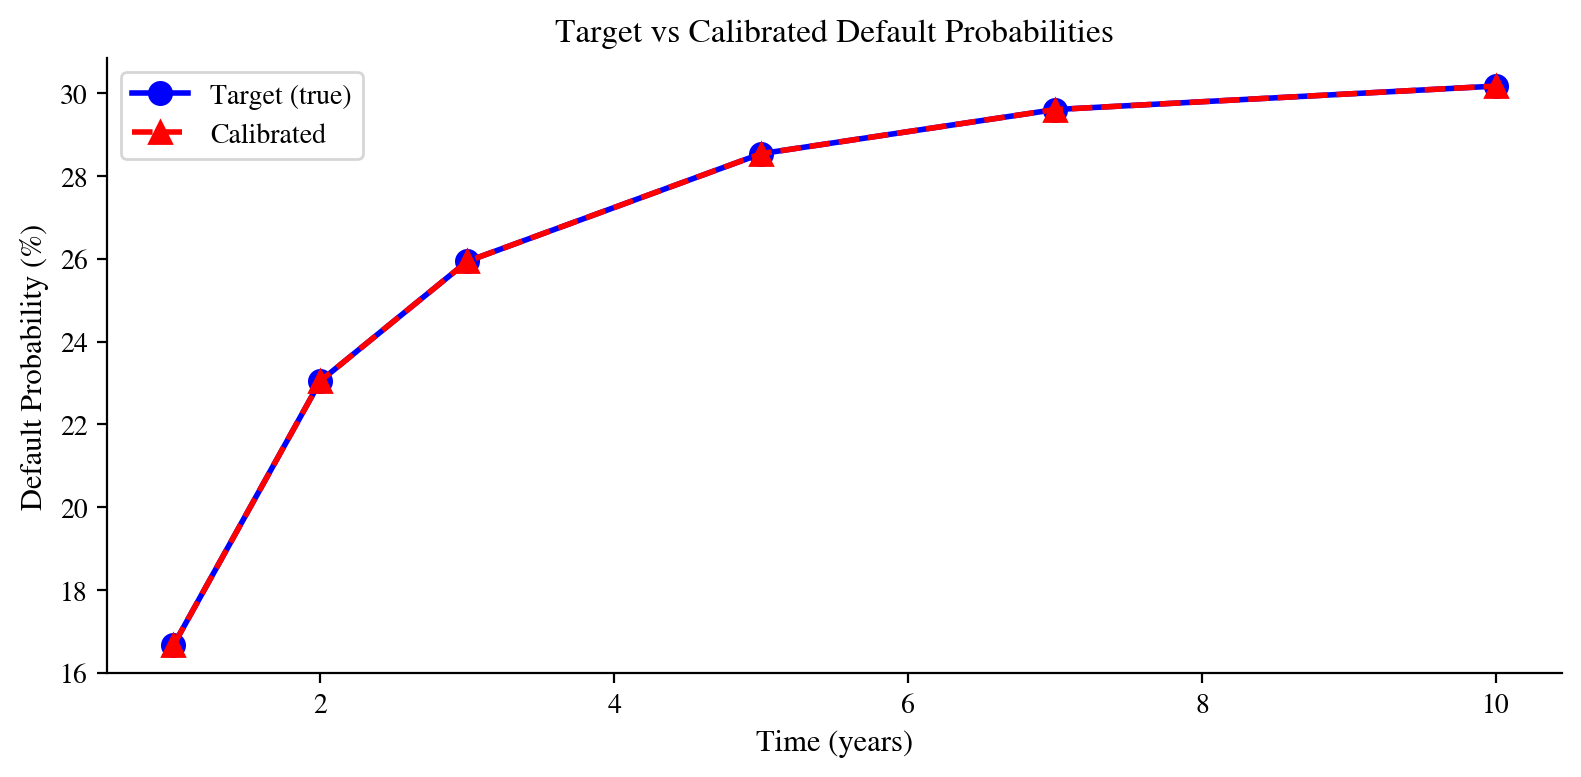

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(maturities, target_PD * 100, 'bo-', lw=2, ms=8, label='Target (true)')
ax.plot(maturities, result['model_values'] * 100, 'r^--', lw=2, ms=8, label='Calibrated')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Default Probability (%)')
ax.set_title('Target vs Calibrated Default Probabilities')
ax.legend()
plt.tight_layout()
plt.show()